In [40]:
# Inputs: processed latest | Process: load SATNAV | Outputs: satnav_df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from pathlib import Path

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

processed_dir = Path("../data/processed")
candidates = sorted(processed_dir.glob("satnav_*.csv"))
csv_path = candidates[-1] if candidates else processed_dir / "satnav_latest.csv"

satnav_df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", satnav_df.shape)

# Inputs: CSV file path | Process: read CSV | Outputs: satnav_tidy DataFrame
from pathlib import Path


# Show all columns (and full column text) when using head(), etc.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

def show_freeze_header(df, height=400):
    html = df.to_html(index=False)
    return HTML(f"""
    <style>
    .scrollbox {{ max-height:{height}px; overflow-y:auto; }}
    .scrollbox thead th {{ position: sticky; top: 0; background: white; z-index: 2; }}
    </style>
    <div class="scrollbox">{html}</div>
    """)


csv_path = Path("../data/processed/satnav_tidy.csv")
satnav_tidy = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.resolve()}")
print(f"Shape: {satnav_tidy.shape}")


Loaded: ../data/processed/satnav_tidy.csv
Shape: (65088, 36)
Loaded: /Users/aaeush/Desktop/Drive/Drive/Academics/Py Project/MyCode/OrbitIQ/orbitiq/data/processed/satnav_tidy.csv
Shape: (65088, 36)


In [65]:
# Inputs: Enhanced style preset | Process: Customize polar axis and remove title/legend | Outputs: Modified enhanced preset

# Modified STYLE_PRESETS with your updated requirements
STYLE_PRESETS: Dict[str, Dict] = {
    "basic": {
        "line_color": None,        # None lets matplotlib choose
        "fill_color": None,        # None -> same as line
        "marker": "o",
        "marker_size": 6,
        "line_width": 2,
        "alpha_fill": 0.25,
        "grid_alpha": 0.5,
        "font_size_cat": 12,
        "font_size_rticks": 10,
        "title_size": 14,
    },
    "enhanced": {
        "line_color": "#434343",           # Accent color connecting line
        "fill_color": "#DEFF9A",           # Accent color fill
        "marker": "o",
        "marker_size": 10,
        "line_width": 4,
        "alpha_fill": 0.6,                 # Fill alpha for accent color
        "grid_alpha": 0.5,
        "font_size_cat": 15,
        "font_size_rticks": 10,
        "title_size": 16,
        "marker_color": "#434343",         # Accent color markers (vertices)
        "label_color": "#434343",            # Black text for value labels
        "label_fontweight": "bold",        # Bold labels
        "background_color": "white",       # White background
        "hide_radial_labels": True,        # Hide radial numbers
        "hide_radial_grid": False,         # Show radial grid
        "hide_axis_labels": True,          # Hide axis labels (category names)
        "hide_data_labels": False,         # Show data value labels
        "hide_title": True,                # Hide title
        "hide_legend": True,               # Hide legend
        "radial_step": 2,                  # Step size for rings
        "radial_alpha": 0.3,               # Keep alpha for grid visibility
        "radial_grid_color": "#434343",      # Polar markings in black
        "label_offset_factor": 0.1,        # 10% more padding
        "hide_outer_circle": True,         # Remove outer circle line
        "polar_axis_color": "darkgray",    # Dark gray polar axis system at the center
    },
    "talkshow": {
        "line_color": "#DEFF9A",
        "fill_color": "#DEFF9A",
        "marker": "o",
        "marker_size": 9,
        "line_width": 3,
        "alpha_fill": 0.4,
        "grid_alpha": 0.35,
        "font_size_cat": 12,
        "font_size_rticks": 20,          # +2 pts on radial numbers
        "title_size": 16,
        "marker_color": "#DEFF9A",       # Accent markers
        "label_color": "black",          # Black value labels
        "label_fontweight": "bold",
        "background_color": "white",
        "hide_radial_labels": True,
        "hide_radial_grid": False,
        "hide_axis_labels": True,
        "hide_data_labels": False,
        "hide_title": True,
        "hide_legend": True,
        "radial_step": 2,
        "radial_alpha": 0.3,
        "radial_grid_color": "black",
        "label_offset_factor": 0.1,
        "hide_outer_circle": True,
        "polar_axis_color": "darkgray",
        "data_label_fontsize": 45        # +2 pts on value labels
    },
    "minimal": {
        "line_color": None,
        "fill_color": None,
        "marker": "o",
        "marker_size": 5,
        "line_width": 2.5,
        "alpha_fill": 0.20,
        "grid_alpha": 0.25,
        "font_size_cat": 11,
        "font_size_rticks": 9,
        "title_size": 13,
    },
}


In [60]:

# Modified create_spider_chart function to handle new styling options
def create_spider_chart(
    prep: SpiderPrepared,
    style: str = "enhanced",
    title: str = "Skillset",
    figsize: Tuple[int, int] = (10, 10),
    show_stats: bool = True,
    label_offset_factor: float = 0.04,     # label offset as fraction of max_value
    radial_step: Optional[float] = None,   # e.g., 1, 2; None -> auto
    save_path: Optional[str] = None,
):
    """
    Create a radar/spider chart from prepared data.

    Orientation:
    - 12 o'clock start (first category at top)
    - CLOCKWISE progression

    Returns
    -------
    fig, ax
    """
    if style not in STYLE_PRESETS:
        raise ValueError(f"Unknown style '{style}'. Available: {list(STYLE_PRESETS)}")
    st = STYLE_PRESETS[style]

    categories = prep.categories
    plot_values = prep.plot_values
    plot_angles = prep.plot_angles
    max_value = float(prep.max_value)

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": "polar"})
    
    # Set background color
    bg_color = st.get("background_color", "white")
    if bg_color == "black":
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
    elif bg_color == "white":
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

    # Put first axis at the top and go CLOCKWISE
    ax.set_theta_offset(math.pi / 2.0)
    ax.set_theta_direction(-1)

    # Axes ticks (one per category, exclude the closing angle)
    ax.set_xticks(plot_angles[:-1])
    
    # Hide axis labels if specified
    if st.get("hide_axis_labels", False):
        ax.set_xticklabels([])  # Remove category labels
    else:
        # Set label color and weight
        label_color = st.get("label_color", "black")
        label_weight = st.get("label_fontweight", "normal")
        ax.set_xticklabels(categories, fontsize=st["font_size_cat"], 
                          fontweight=label_weight, color=label_color)

    # Radial limits & ticks
    ax.set_ylim(0, max_value)
    
    # Custom radial grid with specific rings
    if st.get("hide_radial_labels", False):
        # Hide radial number labels but show rings
        radial_step = st.get("radial_step", 2)
        ring_values = np.arange(radial_step, max_value + radial_step, radial_step)
        ax.set_yticks(ring_values)
        ax.set_yticklabels([])  # Hide the number labels
    else:
        if radial_step is None:
            # choose a simple step ~ 4–6 rings
            desired_rings = 5
            step = max(1, int(round(max_value / desired_rings)))
        else:
            step = radial_step
        ax.set_yticks(np.arange(step, max_value + step, step))
        ax.set_yticklabels([str(int(v)) for v in np.arange(step, max_value + step, step)],
                           fontsize=st["font_size_rticks"])
    
    # Show radial grid with custom alpha and color, but only inside fill area
    # Matplotlib's polar grid is drawn across the full axes by default. To approximate
    # "grid visible only under the filled polygon", we draw the grid very faintly,
    # then overlay a white ring outside the polygon to mask it.
    if not st.get("hide_radial_grid", False):
        radial_alpha = st.get("radial_alpha", 0.3)
        radial_color = st.get("radial_grid_color", "gray")
        # Draw faint global grid first
        ax.grid(alpha=radial_alpha, color=radial_color)
        
        # Build a masking patch that covers everything outside the polygon
        # Create a full circle at max radius in background color, then cut a hole where the fill is
        try:
            from matplotlib.path import Path as MplPath
            from matplotlib.patches import PathPatch
            bg = 'white' if st.get("background_color", "white") == "white" else 'black'
            
            # Outer big circle
            theta = np.linspace(0, 2*np.pi, 512)
            outer = np.c_[theta, np.full_like(theta, max_value)]
            
            # Inner polygon boundary (slightly beyond filled polygon to preserve grid under fill)
            inner = np.c_[plot_angles, np.minimum(max_value, np.array(plot_values) + 1e-6)]
            
            # Build compound path: outer (CCW) and inner (CW) to create a donut hole
            verts = []
            codes = []
            # Outer ring CCW
            verts.append((outer[0,0], outer[0,1]))
            codes.append(MplPath.MOVETO)
            for t, r in outer[1:]:
                verts.append((t, r))
                codes.append(MplPath.LINETO)
            codes[-1] = MplPath.CLOSEPOLY
            
            # Inner ring CW (reverse polygon)
            verts.append((inner[-1,0], inner[-1,1]))
            codes.append(MplPath.MOVETO)
            for t, r in inner[::-1]:
                verts.append((t, r))
                codes.append(MplPath.LINETO)
            codes[-1] = MplPath.CLOSEPOLY
            
            path = MplPath(verts, codes)
            patch = PathPatch(path, facecolor=bg, edgecolor=bg, lw=0)
            # Transform: data coords are (theta, r) in polar; add as artist
            ax.add_patch(patch)
        except Exception:
            pass
    else:
        ax.grid(False)
    
    # Remove outer circle line if specified
    if st.get("hide_outer_circle", False):
        ax.spines['polar'].set_visible(False)

    # Set polar axis (spine/ticks) to dark gray
    for spine in ax.spines.values():
        spine.set_color(st.get("polar_axis_color", "darkgray"))
    ax.tick_params(colors=st.get("polar_axis_color", "darkgray"))

    # Plot line and fill
    line_color = st["line_color"]               # Black connecting line
    fill_color = st["fill_color"] if st["fill_color"] is not None else line_color
    marker_color = st.get("marker_color", "#DEFF9A")  # Accent markers
    
    (ln,) = ax.plot(
        plot_angles,
        plot_values,
        marker=st["marker"],
        markersize=st["marker_size"],
        linewidth=st["line_width"],
        color=line_color,
        markerfacecolor=marker_color,
        markeredgecolor=marker_color,
        label="Expertise"
    )
    ax.fill(plot_angles, plot_values, alpha=st["alpha_fill"], color=fill_color or ln.get_color())

    # Value labels near vertices - only show if not hidden
    if not st.get("hide_data_labels", False):
        label_offset_factor = st.get("label_offset_factor", 0.04)
        label_offset = max_value * label_offset_factor
        label_color = st.get("label_color", "black")
        value_fontsize = st.get("data_label_fontsize", 25)
        for angle, val, cat in zip(plot_angles[:-1], prep.values, categories):
            ax.text(
                angle,
                min(max_value, val + label_offset),
                f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=value_fontsize,
                fontweight="bold",
                color=label_color,
            )

    # Title - only show if not hidden
    if not st.get("hide_title", False):
        ax.set_title(title, fontsize=st["title_size"], pad=18, fontweight="bold", color=st.get("label_color", "black"))

    # Legend - only show if not hidden
    if not st.get("hide_legend", False):
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.05))

    plt.tight_layout()

    if show_stats:
        s = prep.stats
        print("=== SKILLS SUMMARY ===")
        print(f"Skills: {s['total_skills']}, Avg: {s['average']:.2f}, "
              f"Max: {s['max']:.2f}, Min: {s['min']:.2f}, Range: {s['range']:.2f}")

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    return fig, ax

=== SKILLS SUMMARY ===
Skills: 6, Avg: 8.30, Max: 9.20, Min: 6.80, Range: 2.40


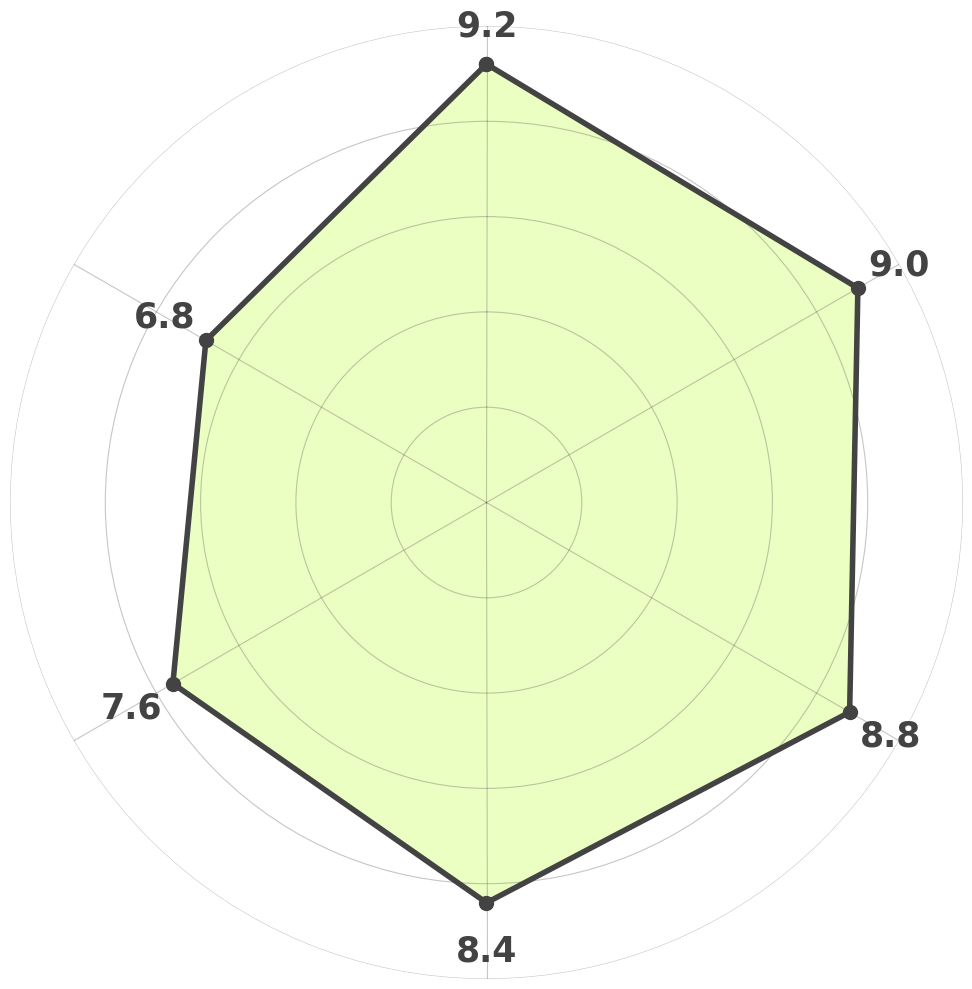

In [66]:
if __name__ == "__main__":
    skills_data = {
        "Skill": ["Execution", "Decision Science", "Storytelling", "Stakeholder mgmt", "Research skills", "Strategic acumen"],
        "Expertise": [9.2, 9.0, 8.8, 8.4, 7.6, 6.8]
    }

    # Keep input order (Execution first) so it lands at 12 o’clock; auto-scale to max=10
    prep = prepare_spider_data(skills_data, max_value=10, clamp=False, sort_desc=False)
    fig, ax = create_spider_chart(prep, style="enhanced", title="Skillset")
    plt.show()


🎨 Updated Spider Chart Features:
   ✅ White background
   ✅ Black markers (vertices)
   ✅ Dark gray polar coordinates
   ✅ No outer circle line
   ✅ Accent color (#DEFF9A) fill with alpha 0.4
   ✅ Grid alpha 0.1

=== SKILLS SUMMARY ===
Skills: 6, Avg: 8.30, Max: 9.20, Min: 6.80, Range: 2.40


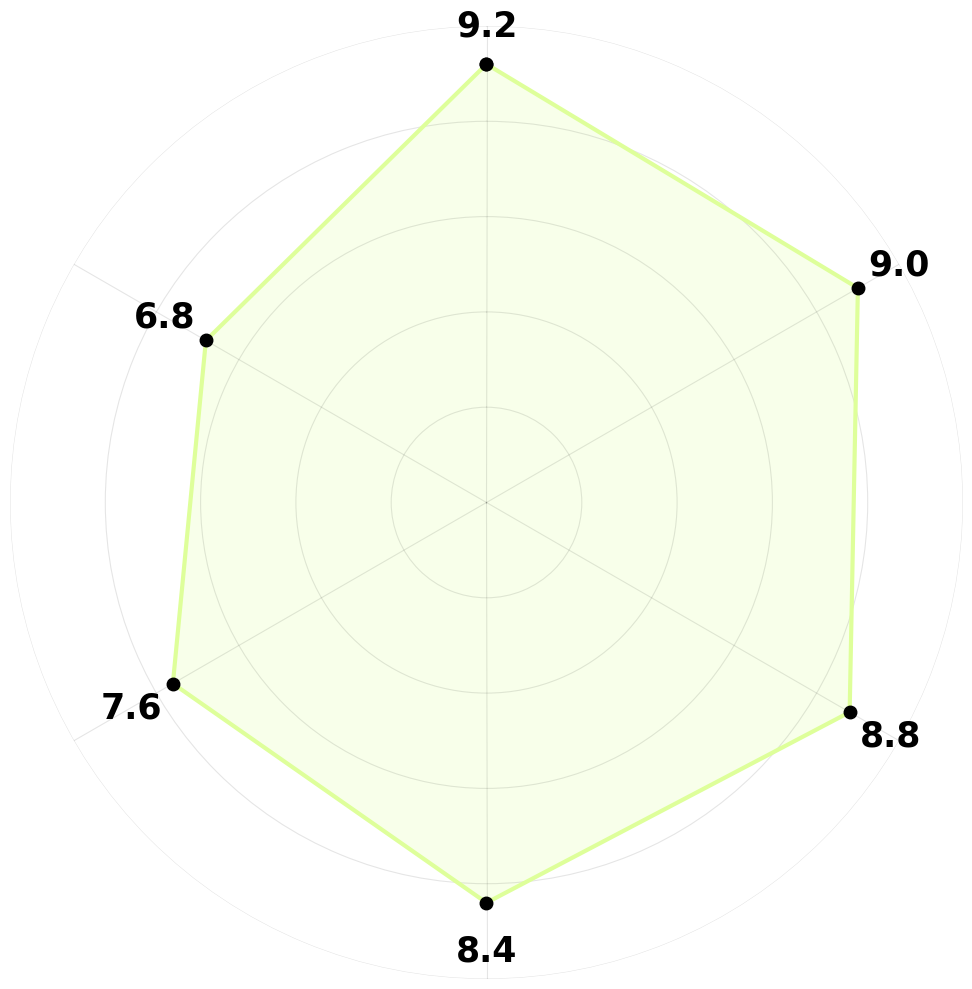

In [52]:
# Test the updated spider chart with refined styling
print("🎨 Updated Spider Chart Features:")
print("   ✅ White background")
print("   ✅ Black markers (vertices)") 
print("   ✅ Dark gray polar coordinates")
print("   ✅ No outer circle line")
print("   ✅ Accent color (#DEFF9A) fill with alpha 0.4")
print("   ✅ Grid alpha 0.1")
print()

# Test with sample data
skills_data = {
    "Skill": ["Execution", "Decision Science", "Storytelling", "Stakeholder mgmt", "Research skills", "Strategic acumen"],
    "Expertise": [9.2, 9.0, 8.8, 8.4, 7.6, 6.8]
}

prep = prepare_spider_data(skills_data, max_value=10, clamp=False, sort_desc=False)
fig, ax = create_spider_chart(prep, style="enhanced", title="Refined Skillset Chart")
plt.show()
